<a href="https://colab.research.google.com/github/usembergstarling-cmyk/google-colabt/blob/main/Copia_de_Copia_de_Analisis_predictivo_de_preciosBOGOTAAAAAAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo y de Clasificación de Precios de Vivienda en Bogotá
Este cuaderno compara tres modelos de aprendizaje automático (Regresión Lineal, Regresión Polinomial y Regresión Logística) para analizar y predecir el mercado inmobiliario de Bogotá basándose en sus características físicas y de ubicación.

### 1. Contextualización del Proyecto
Este análisis está diseñado específicamente para estudiar la dinámica del mercado inmobiliario en la ciudad de **Bogotá, Colombia**. Evaluamos tres metodologías de aprendizaje supervisado sobre un set de datos de vivienda con el fin de resolver problemas de estimación de costos y de clasificación de inversión:

In [ ]:
# 1. Importamos la biblioteca 'pandas' con el alias 'pd' para habilitar estructuras de datos bidimensionales de alta eficiencia llamadas DataFrames
import pandas as pd

# 2. Definimos una variable de tipo string 'archivo_bogota' que contiene la ruta absoluta donde se almacenó el archivo CSV en el entorno virtual de trabajo
archivo_bogota = '/content/Housing_Bogota.csv'

# 3. Iniciamos un bloque de control de excepciones 'try' para capturar posibles errores de entrada/salida (I/O) durante la lectura del almacenamiento
try:
    # 4. Invocamos el método '.read_csv()' de pandas pasándole la ruta del archivo para deserializar el CSV en una estructura de datos estructurada 'df'
    df = pd.read_csv(archivo_bogota)

    # 5. Utilizamos la función de salida por pantalla 'print()' para mostrar un mensaje informando el éxito de la carga de datos en el sistema
    print("¡Archivo de datos de Bogotá cargado correctamente en el DataFrame de trabajo!")

    # 6. Invocamos la función interactiva 'display()' nativa del entorno de Jupyter/Colab para formatear estéticamente el DataFrame
    # 7. Usamos la función miembro '.head()' del DataFrame para obtener los primeros 5 registros de la tabla y pasárselos como argumento a 'display'
    display(df.head())

# 8. Declaramos la instrucción 'except' asociando la clase base 'Exception' con la variable 'e' para capturar de manera segura cualquier error imprevisto de lectura
except Exception as e:
    # 9. Imprimimos una f-string que interpola la representación en cadena de caracteres de la excepción 'e' para diagnosticar el fallo en la consola
    print(f"Error al leer el archivo local de Bogotá: {e}")

¡Archivo de datos de Bogotá cargado correctamente en el DataFrame de trabajo!


,area_m2,habitaciones,banos,estrato,localidad,precio_millones
0,132.352137,3,2,3,Chapinero,1168.925487
1,103.778106,3,3,3,Chapinero,1009.319212
2,139.145984,2,1,4,Suba,896.131529
3,178.536344,5,4,4,Usaquén,1395.616072
4,99.463098,3,3,6,Usaquén,1050.275757


### Generación del Conjunto de Datos Sintético
En esta sección, generamos un conjunto de datos sintético representativo del mercado inmobiliario de Bogotá. Este dataset incluye características como área en m², número de habitaciones y baños, estrato socioeconómico, localidad y precio estimado, simulando una base de datos para el análisis predictivo.

In [ ]:
import pandas as pd # Importamos la librería 'pandas' usando el alias estándar 'pd' para la manipulación y análisis de datos tabulares estructurados
import numpy as np # Importamos la biblioteca 'numpy' bajo el alias 'np' para realizar operaciones numéricas vectorizadas de alto rendimiento

# Establecemos una semilla fija llamando a 'np.random.seed()' para garantizar la reproducibilidad matemática de las muestras aleatorias
np.random.seed(42)

# Declaramos una variable de tipo entero llamada 'n_viviendas' para definir la dimensión o cantidad de registros de nuestro dataset
n_viviendas = 500

# Generamos una distribución normal para el área de los inmuebles utilizando 'np.random.normal()', recortando los extremos con '.clip()'
areas = np.random.normal(loc=110, scale=45, size=n_viviendas).clip(40, 400)

# Seleccionamos muestras de habitaciones usando 'np.random.choice()' asignando un vector de probabilidades sesgadas al parámetro 'p'
habitaciones = np.random.choice([1, 2, 3, 4, 5], size=n_viviendas, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# Calculamos el número de baños restando un entero aleatorio binario al array 'habitaciones' y forzamos límites entre 1 y 4 usando '.clip()'
banos = (habitaciones - np.random.choice([0, 1], size=n_viviendas, p=[0.7, 0.3])).clip(1, 4)

# Generamos los estratos socioeconómicos representativos de Bogotá mediante muestreos discretos de probabilidad ponderada en 'np.random.choice()'
estrato = np.random.choice([2, 3, 4, 5, 6], size=n_viviendas, p=[0.2, 0.3, 0.25, 0.15, 0.1])

# Creamos una lista de localidades categóricas de Bogotá seleccionadas uniformemente al azar mediante 'np.random.choice()'
localidades = np.random.choice(['Usaquén', 'Chapinero', 'Suba', 'Kennedy', 'Engativá'], size=n_viviendas)

# Calculamos un precio base por m2 ponderado según factores lineales para simular una relación matemática subyacente
precios_base = (areas * 3.5) + (estrato * 50) + (habitaciones * 15) + (banos * 20)

# Definimos un diccionario de mapeo llave-valor para guardar el factor de multiplicación de costo de suelo por localidad
multiplicadores_localidad = {'Usaquén': 1.4, 'Chapinero': 1.6, 'Suba': 1.2, 'Kennedy': 0.8, 'Engativá': 0.9}

# Aplicamos una lista de comprensión de Python para calcular el precio final de cada vivienda multiplicando la base por el factor geográfico
precios_finales = [precios_base[i] * multiplicadores_localidad[localidades[i]] for i in range(n_viviendas)]

# Agregamos ruido gaussiano con 'np.random.normal()' y recortamos los límites de precios viables usando la función '.clip()' de numpy
precios = (np.array(precios_finales) + np.random.normal(loc=0, scale=30, size=n_viviendas)).clip(80, 1800)

# Instanciamos la clase 'pd.DataFrame' pasando un diccionario de Python para estructurar nuestras columnas y series de datos
df_bogota = pd.DataFrame({
    'area_m2': areas,
    'habitaciones': habitaciones,
    'banos': banos,
    'estrato': estrato,
    'localidad': localidades,
    'precio_millones': precios
})

# Guardamos la estructura del DataFrame en un archivo de texto separado por comas empleando la función '.to_csv()' indicando omitir índices de fila
df_bogota.to_csv('/content/Housing_Bogota.csv', index=False)

# Imprimimos un mensaje informativo en pantalla mediante la función nativa 'print()' de Python
print("¡Conjunto de datos de viviendas de Bogotá generado y guardado exitosamente en la ruta local!")

# Usamos la función interactiva 'display()' de Colab para plasmar una vista previa estética de las primeras cinco filas obtenidas con '.head()'
display(df_bogota.head())

¡Conjunto de datos de viviendas de Bogotá generado y guardado exitosamente en la ruta local!


,area_m2,habitaciones,banos,estrato,localidad,precio_millones
0,132.352137,3,2,3,Chapinero,1168.925487
1,103.778106,3,3,3,Chapinero,1009.319212
2,139.145984,2,1,4,Suba,896.131529
3,178.536344,5,4,4,Usaquén,1395.616072
4,99.463098,3,3,6,Usaquén,1050.275757


### Preparación de Datos y Transformación de Características
Aquí llevamos a cabo la preparación de los datos para el entrenamiento de los modelos. Esto incluye la conversión de variables categóricas (localidad) a formato numérico mediante codificación 'one-hot' y la creación de una variable objetivo binaria para clasificación ('alto_costo') basada en la mediana de los precios. También se realiza la división del dataset en conjuntos de entrenamiento y prueba, y la transformación de características para la regresión polinomial.

### Descarga del Conjunto de Datos
La siguiente celda te permite descargar directamente a tu equipo local el archivo CSV generado con los datos inmobiliarios de Bogotá.

In [ ]:
# 1. Desde la librería integrada de Google Colab 'google.colab', procedemos a importar específicamente la clase de utilidad 'files' para interactuar con el gestor de descargas del navegador
from google.colab import files

# 2. Invocamos de manera explícita la función miembro '.download()' de la clase 'files', proporcionando como argumento de entrada de tipo string la ruta absoluta del archivo CSV en el servidor local de Colab ('/content/Housing_Bogota.csv') para forzar la transferencia del archivo de datos al almacenamiento local del usuario
files.download('/content/Housing_Bogota.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
### 2. Preparación de Datos e Ingeniería de Características
Para que los algoritmos de Scikit-Learn comprendan los datos categóricos, convertimos las localidades en variables dummy binarias ($0$ o $1$) omitiendo la primera para evitar multicolinealidad. Adicionalmente, segmentamos el conjunto en un $80\%$ para entrenamiento y un $20\%$ para validación, y extraemos el umbral de la mediana del mercado para crear nuestra variable objetivo binaria de alto costo.

Datos preparados correctamente


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,9158483,5745,3,2,2,3,True,True,False,False,True,True,False,False
1,9445182,4792,5,1,3,1,True,False,True,False,True,True,True,False
2,7692424,5971,4,2,2,2,False,False,False,True,True,False,True,False
3,9654445,7284,5,1,1,1,True,False,True,False,True,False,False,True
4,5824459,4648,2,2,1,1,False,False,False,False,False,False,False,False


### Entrenamiento de Modelos de Regresión y Clasificación
En este bloque se procede al entrenamiento de los tres modelos de aprendizaje automático: Regresión Lineal, Regresión Polinomial y Regresión Logística. Cada modelo se ajusta a los datos de entrenamiento y se evalúa su rendimiento utilizando métricas específicas para regresión (MAE, R²) y clasificación (Accuracy).

In [ ]:
import pandas as pd # Importamos 'pandas' para leer el archivo CSV y procesar la dummificación de variables categóricas
import numpy as np # Importamos 'numpy' para realizar cálculos y transformaciones de estructuras matriciales complejas
from sklearn.model_selection import train_test_split # Importamos 'train_test_split' para segregar el dataset en entrenamiento y prueba
from sklearn.preprocessing import PolynomialFeatures # Importamos el transformador de extracción de variables polinómicas y cruzadas de grado N

# Invocamos la función 'pd.read_csv()' para leer y cargar los registros del dataset de vivienda en un DataFrame llamado 'df'
df = pd.read_csv('/content/Housing_Bogota.csv')

# Ejecutamos 'pd.get_dummies()' sobre 'df' en la columna 'localidad', indicando 'drop_first=True' para omitir la primera categoría y evitar colinealidad
df = pd.get_dummies(df, columns=['localidad'], drop_first=True)

# Extraemos la mediana del precio continuo calculando con la función agregadora '.median()' del vector columna 'precio_millones'
mediana_precio = df['precio_millones'].median()

# Creamos una columna lógica 'alto_costo' aplicando una condición mayor que la mediana y casteando la respuesta booleana a entero binario mediante '.astype(int)'
df['alto_costo'] = (df['precio_millones'] > mediana_precio).astype(int)

# Obtenemos la matriz de características independiente 'X' removiendo las variables de precio y de clasificación mediante el método '.drop()'
X = df.drop(columns=['precio_millones', 'alto_costo'])

# Extraemos el vector de variable dependiente continuo para regresión mapeando directamente la columna 'precio_millones' a 'y_reg'
y_reg = df['precio_millones']

# Extraemos el vector de variable objetivo discreto/binario asignando la columna 'alto_costo' a la variable 'y_clf'
y_clf = df['alto_costo']

# Dividimos 'X' e 'y_reg' utilizando 'train_test_split()', especificando un tamaño de test del 20% y fijando el estado del generador en 42
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Dividimos paralelamente las etiquetas de clasificación 'y_clf' con la misma semilla aleatoria para emparejar la distribución de filas
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Instanciamos 'PolynomialFeatures' configurando el grado en 2 y excluyendo el término de sesgo constante ('include_bias=False')
poli_transformador = PolynomialFeatures(degree=2, include_bias=False)

# Ajustamos el transformador y obtenemos las interacciones no lineales de entrenamiento llamando a '.fit_transform()' con 'X_train'
X_train_poli = poli_transformador.fit_transform(X_train)

# Aplicamos la misma regla dimensional entrenada para transformar el conjunto independiente de pruebas usando '.transform()' con 'X_test'
X_test_poli = poli_transformador.transform(X_test)

# Mostramos mensajes formateados en consola usando f-strings para imprimir los conteos dimensionales del método '.shape'
print(f"Datos de Bogotá preparados con éxito.")
print(f"Características de Regresión Lineal: {X_train.shape[1]}")
print(f"Características de Regresión Polinomial (Grado 2): {X_train_poli.shape[1]}")

Datos de Bogotá preparados con éxito.
Características de Regresión Lineal: 8
Características de Regresión Polinomial (Grado 2): 44


### Entrenamiento Detallado y Evaluación Consolidada de Modelos
Esta sección reitera el entrenamiento y evaluación de los modelos de regresión lineal, polinomial y logística, consolidando las métricas de rendimiento obtenidas para una comparación directa y detallada de cada algoritmo.

### Entrenamiento de Modelos con Sintaxis Ultra-Detallada
A continuación, entrenamos los modelos de Regresión Lineal, Regresión Polinomial y Regresión Logística. Cada línea de código está explicada detalladamente para comprender la sintaxis de las librerías científicas.

### Área de Regresión Lineal Múltiple
En esta sección se entrena y evalúa el modelo de Regresión Lineal para predecir de forma continua el precio de las viviendas.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# --- GENERACIÓN / CARGA SEGURA DE DATOS (Independiente) ---
ruta_csv = '/content/Housing_Bogota.csv'
if not os.path.exists(ruta_csv):
    np.random.seed(42)
    n_viviendas = 500
    areas = np.random.normal(loc=110, scale=45, size=n_viviendas).clip(40, 400)
    habitaciones = np.random.choice([1, 2, 3, 4, 5], size=n_viviendas, p=[0.1, 0.3, 0.4, 0.15, 0.05])
    banos = (habitaciones - np.random.choice([0, 1], size=n_viviendas, p=[0.7, 0.3])).clip(1, 4)
    estrato = np.random.choice([2, 3, 4, 5, 6], size=n_viviendas, p=[0.2, 0.3, 0.25, 0.15, 0.1])
    localidades = np.random.choice(['Usaquén', 'Chapinero', 'Suba', 'Kennedy', 'Engativá'], size=n_viviendas)
    precios_base = (areas * 3.5) + (estrato * 50) + (habitaciones * 15) + (banos * 20)
    multiplicadores_localidad = {'Usaquén': 1.4, 'Chapinero': 1.6, 'Suba': 1.2, 'Kennedy': 0.8, 'Engativá': 0.9}
    precios_finales = [precios_base[i] * multiplicadores_localidad[localidades[i]] for i in range(n_viviendas)]
    precios = (np.array(precios_finales) + np.random.normal(loc=0, scale=30, size=n_viviendas)).clip(80, 1800)
    df_temp = pd.DataFrame({
        'area_m2': areas, 'habitaciones': habitaciones, 'banos': banos,
        'estrato': estrato, 'localidad': localidades, 'precio_millones': precios
    })
    os.makedirs(os.path.dirname(ruta_csv), exist_ok=True)
    df_temp.to_csv(ruta_csv, index=False)

df = pd.read_csv(ruta_csv)
df = pd.get_dummies(df, columns=['localidad'], drop_first=True)
X = df.drop(columns=['precio_millones'])
y_reg = df['precio_millones']
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# --- ENTRENAMIENTO Y EVALUACIÓN ---
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train_reg)
predicciones_lineales = modelo_lineal.predict(X_test)

mae_lineal = mean_absolute_error(y_test_reg, predicciones_lineales)
r2_lineal = r2_score(y_test_reg, predicciones_lineales)

print("=== MÉTRICAS REGRESIÓN LINEAL ===")
print(f"MAE: {mae_lineal:.2f} millones de COP | R²: {r2_lineal:.4f}")

=== MÉTRICAS REGRESIÓN LINEAL ===
MAE: 36.41 millones de COP | R²: 0.9677


### Área de Regresión Polinomial (Grado 2)
En esta sección se entrena y evalúa el modelo de Regresión Polinomial utilizando las características expandidas para capturar relaciones no lineales.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# --- GENERACIÓN / CARGA SEGURA DE DATOS (Independiente) ---
ruta_csv = '/content/Housing_Bogota.csv'
if not os.path.exists(ruta_csv):
    np.random.seed(42)
    n_viviendas = 500
    areas = np.random.normal(loc=110, scale=45, size=n_viviendas).clip(40, 400)
    habitaciones = np.random.choice([1, 2, 3, 4, 5], size=n_viviendas, p=[0.1, 0.3, 0.4, 0.15, 0.05])
    banos = (habitaciones - np.random.choice([0, 1], size=n_viviendas, p=[0.7, 0.3])).clip(1, 4)
    estrato = np.random.choice([2, 3, 4, 5, 6], size=n_viviendas, p=[0.2, 0.3, 0.25, 0.15, 0.1])
    localidades = np.random.choice(['Usaquén', 'Chapinero', 'Suba', 'Kennedy', 'Engativá'], size=n_viviendas)
    precios_base = (areas * 3.5) + (estrato * 50) + (habitaciones * 15) + (banos * 20)
    multiplicadores_localidad = {'Usaquén': 1.4, 'Chapinero': 1.6, 'Suba': 1.2, 'Kennedy': 0.8, 'Engativá': 0.9}
    precios_finales = [precios_base[i] * multiplicadores_localidad[localidades[i]] for i in range(n_viviendas)]
    precios = (np.array(precios_finales) + np.random.normal(loc=0, scale=30, size=n_viviendas)).clip(80, 1800)
    df_temp = pd.DataFrame({
        'area_m2': areas, 'habitaciones': habitaciones, 'banos': banos,
        'estrato': estrato, 'localidad': localidades, 'precio_millones': precios
    })
    os.makedirs(os.path.dirname(ruta_csv), exist_ok=True)
    df_temp.to_csv(ruta_csv, index=False)

df = pd.read_csv(ruta_csv)
df = pd.get_dummies(df, columns=['localidad'], drop_first=True)
X = df.drop(columns=['precio_millones'])
y_reg = df['precio_millones']
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Transformación Polinomial de Grado 2
poli_transformador = PolynomialFeatures(degree=2, include_bias=False)
X_train_poli = poli_transformador.fit_transform(X_train)
X_test_poli = poli_transformador.transform(X_test)

# --- ENTRENAMIENTO Y EVALUACIÓN ---
modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_train_poli, y_train_reg)
predicciones_polinomiales = modelo_polinomial.predict(X_test_poli)

mae_polinomial = mean_absolute_error(y_test_reg, predicciones_polinomiales)
r2_polinomial = r2_score(y_test_reg, predicciones_polinomiales)

print("=== MÉTRICAS REGRESIÓN POLINOMIAL ===")
print(f"MAE: {mae_polinomial:.2f} millones de COP | R²: {r2_polinomial:.4f}")

=== MÉTRICAS REGRESIÓN POLINOMIAL ===
MAE: 24.36 millones de COP | R²: 0.9872


### Área de Regresión Logística (Clasificación)
En esta sección se entrena el modelo clasificador para predecir si una vivienda es de alto costo basándose en la mediana de los precios de Bogotá.

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- GENERACIÓN / CARGA SEGURA DE DATOS (Independiente) ---
ruta_csv = '/content/Housing_Bogota.csv'
if not os.path.exists(ruta_csv):
    np.random.seed(42)
    n_viviendas = 500
    areas = np.random.normal(loc=110, scale=45, size=n_viviendas).clip(40, 400)
    habitaciones = np.random.choice([1, 2, 3, 4, 5], size=n_viviendas, p=[0.1, 0.3, 0.4, 0.15, 0.05])
    banos = (habitaciones - np.random.choice([0, 1], size=n_viviendas, p=[0.7, 0.3])).clip(1, 4)
    estrato = np.random.choice([2, 3, 4, 5, 6], size=n_viviendas, p=[0.2, 0.3, 0.25, 0.15, 0.1])
    localidades = np.random.choice(['Usaquén', 'Chapinero', 'Suba', 'Kennedy', 'Engativá'], size=n_viviendas)
    precios_base = (areas * 3.5) + (estrato * 50) + (habitaciones * 15) + (banos * 20)
    multiplicadores_localidad = {'Usaquén': 1.4, 'Chapinero': 1.6, 'Suba': 1.2, 'Kennedy': 0.8, 'Engativá': 0.9}
    precios_finales = [precios_base[i] * multiplicadores_localidad[localidades[i]] for i in range(n_viviendas)]
    precios = (np.array(precios_finales) + np.random.normal(loc=0, scale=30, size=n_viviendas)).clip(80, 1800)
    df_temp = pd.DataFrame({
        'area_m2': areas, 'habitaciones': habitaciones, 'banos': banos,
        'estrato': estrato, 'localidad': localidades, 'precio_millones': precios
    })
    os.makedirs(os.path.dirname(ruta_csv), exist_ok=True)
    df_temp.to_csv(ruta_csv, index=False)

df = pd.read_csv(ruta_csv)
df = pd.get_dummies(df, columns=['localidad'], drop_first=True)
mediana_precio = df['precio_millones'].median()
df['alto_costo'] = (df['precio_millones'] > mediana_precio).astype(int)

X = df.drop(columns=['precio_millones', 'alto_costo'])
y_clf = df['alto_costo']
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# --- ENTRENAMIENTO Y EVALUACIÓN ---
modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train, y_train_clf)
predicciones_logisticas = modelo_logistico.predict(X_test)

exactitud_logistica = accuracy_score(y_test_clf, predicciones_logisticas)

print("=== MÉTRICAS REGRESIÓN LOGÍSTICA ===")
print(f"Exactitud (Accuracy): {exactitud_logistica * 100:.2f}%")

=== MÉTRICAS REGRESIÓN LOGÍSTICA ===
Exactitud (Accuracy): 94.00%


In [ ]:
# 1. De la biblioteca 'sklearn' (Scikit-Learn), específicamente de su paquete secundario 'linear_model', importamos la clase 'LinearRegression' para el modelado de regresión lineal
from sklearn.linear_model import LinearRegression

# 2. Del paquete secundario 'linear_model' de la biblioteca 'sklearn', importamos la clase 'LogisticRegression' para entrenar algoritmos de clasificación estadística
from sklearn.linear_model import LogisticRegression

# 3. Del paquete secundario 'metrics' de la biblioteca 'sklearn', importamos de forma selectiva tres funciones métricas: 'mean_absolute_error', 'r2_score' y 'accuracy_score'
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# =========================================================================
# --- SECCIÓN 1: ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN LINEAL MULTIPLE ---
# =========================================================================

# 4. Instanciamos la clase 'LinearRegression' invocando su constructor por defecto sin argumentos y asignamos el objeto de estimación a la variable local 'modelo_lineal'
modelo_lineal = LinearRegression()

# 5. Ejecutamos el método '.fit()' del objeto 'modelo_lineal' pasando 'X_train' (datos de características de entrenamiento) y 'y_train_reg' (precios objetivos continuos de entrenamiento) para calcular los coeficientes de regresión óptimos mediante mínimos cuadrados ordinarios
modelo_lineal.fit(X_train, y_train_reg)

# 6. Llamamos al método predictivo '.predict()' del objeto ajustado 'modelo_lineal' pasando la matriz de validación 'X_test' para obtener el vector de predicciones en la variable 'predicciones_lineales'
predicciones_lineales = modelo_lineal.predict(X_test)

# 7. Invocamos la función matemática 'mean_absolute_error()' pasando el vector de etiquetas reales 'y_test_reg' y las estimaciones 'predicciones_lineales' para hallar el promedio de las desviaciones absolutas entre la realidad y la predicción
mae_lineal = mean_absolute_error(y_test_reg, predicciones_lineales)

# 8. Llamamos a la función estadística 'r2_score()' pasando los valores observados de test 'y_test_reg' y los pronósticos 'predicciones_lineales' para calcular la proporción de la varianza dependiente explicada de 0 a 1
r2_lineal = r2_score(y_test_reg, predicciones_lineales)

# =========================================================================
# --- SECCIÓN 2: ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN POLINOMIAL -----
# =========================================================================

# 9. Creamos un nuevo objeto estimador independiente de la clase 'LinearRegression' y lo guardamos bajo el identificador de variable 'modelo_polinomial'
modelo_polinomial = LinearRegression()

# 10. Ajustamos el modelo lineal entrenándolo con '.fit()' a partir de las columnas transformadas de grado 2 'X_train_poli' y las etiquetas reales del precio 'y_train_reg'
modelo_polinomial.fit(X_train_poli, y_train_reg)

# 11. Ejecutamos '.predict()' en el estimador 'modelo_polinomial' utilizando la matriz expandida de test 'X_test_poli' para estimar los precios continuos no lineales transformados
predicciones_polinomiales = modelo_polinomial.predict(X_test_poli)

# 12. Evaluamos el rendimiento absoluto del modelo polinomial invocando 'mean_absolute_error()' con los vectores de precios reales 'y_test_reg' y estimados 'predicciones_polinomiales'
mae_polinomial = mean_absolute_error(y_test_reg, predicciones_polinomiales)

# 13. Determinamos el ajuste del modelo polinomial calculando el coeficiente de determinación con 'r2_score()' empleando 'y_test_reg' y 'predicciones_polinomiales'
r2_polinomial = r2_score(y_test_reg, predicciones_polinomiales)

# =========================================================================
# --- SECCIÓN 3: ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN LOGÍSTICA --------
# =========================================================================

# 14. Instanciamos un clasificador asignándole la clase 'LogisticRegression' especificando mediante el parámetro con nombre 'max_iter' el número máximo de iteraciones fijado en 1000 para evitar que el solucionador numérico falle por falta de convergencia
modelo_logistico = LogisticRegression(max_iter=1000)

# 15. Entrenamos el objeto clasificador binario 'modelo_logistico' con '.fit()' usando las características originales sin alterar 'X_train' junto a la etiqueta binaria estructurada de alto costo 'y_train_clf'
modelo_logistico.fit(X_train, y_train_clf)

# 16. Obtenemos el vector de decisiones binarias del clasificador usando '.predict()' sobre la matriz 'X_test' para almacenar los resultados mapeados (0 y 1) en la variable 'predicciones_logisticas'
predicciones_logisticas = modelo_logistico.predict(X_test)

# 17. Computamos la tasa de acierto del modelo utilizando 'accuracy_score()' pasándole las clases observadas 'y_test_clf' y las predichas 'predicciones_logisticas' para obtener el porcentaje de aciertos globales
exactitud_logistica = accuracy_score(y_test_clf, predicciones_logisticas)

# 18. Imprimimos una cabecera de reporte estético mediante la función estándar de salida 'print()' que interpreta la cadena de caracteres suministrada
print("=== MÉTRICAS OBTENIDAS PARA LOS MODELOS DE BOGOTÁ ===\n")

# 19. Desplegamos la evaluación formateada de la Regresión Lineal estructurando un f-string con formato numérico de dos decimales para el MAE (:.2f) y cuatro para el coeficiente de determinación (:.4f)
print(f"[Regresión Lineal]      MAE: {mae_lineal:.2f} millones de COP | R²: {r2_lineal:.4f}")

# 20. Desplegamos de la misma forma las métricas de la Regresión Polinomial incrustando los valores de las variables 'mae_polinomial' y 'r2_polinomial' formateados en su respectiva notación decimal
print(f"[Regresión Polinomial]  MAE: {mae_polinomial:.2f} millones de COP | R²: {r2_polinomial:.4f}")

# 21. Imprimimos el porcentaje de exactitud del modelo logístico multiplicando por 100 la variable 'exactitud_logistica' con un redondeo estricto de dos puntos decimales seguido del símbolo '%' para denotar el rendimiento relativo
print(f"[Regresión Logística]   Exactitud (Accuracy): {exactitud_logistica * 100:.2f}%")

=== MÉTRICAS OBTENIDAS PARA LOS MODELOS DE BOGOTÁ ===

[Regresión Lineal]      MAE: 36.41 millones de COP | R²: 0.9677
[Regresión Polinomial]  MAE: 24.36 millones de COP | R²: 0.9872
[Regresión Logística]   Exactitud (Accuracy): 94.00%


### Comparación de Rendimiento de Algoritmos y Visualización de Resultados
Aquí se visualizan los resultados de los modelos para una comprensión más intuitiva de su desempeño. Se presentan gráficos comparativos del Error Medio Absoluto (MAE) para los modelos de regresión y una visualización de la clasificación del modelo logístico frente a los precios reales.

In [ ]:
### Comparación del rendimiento de los Algoritmos de Regresión
Para predecir el valor continuo en millones de pesos colombianos (COP), comparamos un modelo de regresión lineal simple contra una expansión de características polinomiales de segundo grado que captura patrones no lineales. Como se evidenció en los resultados del bloque anterior, la inclusión de términos cuadráticos reduce significativamente la métrica de error absoluto (MAE) de las estimaciones.

Error de Regresión Lineal (MAE): 656,919.65
Error de Árbol de Decisión (MAE): 1,095,826.49

Análisis: La Regresión Lineal tuvo un mejor rendimiento al tener un error menor.


In [ ]:
from sklearn.linear_model import LinearRegression # Para el modelo de regresión lineal
from sklearn.linear_model import LogisticRegression # Para el modelo de regresión logística
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score # Métricas de evaluación

# --- 1. MODELO DE REGRESIÓN LINEAL ---
modelo_lineal = LinearRegression() # Inicializamos el objeto del estimador lineal
modelo_lineal.fit(X_train, y_train_reg) # Ajustamos el modelo con los datos de entrenamiento
predicciones_lineales = modelo_lineal.predict(X_test) # Realizamos las predicciones continuas
mae_lineal = mean_absolute_error(y_test_reg, predicciones_lineales) # Calculamos el Error Medio Absoluto
r2_lineal = r2_score(y_test_reg, predicciones_lineales) # Calculamos el coeficiente de determinación R2

# --- 2. MODELO DE REGRESIÓN POLINOMIAL (Grado 2) ---
modelo_polinomial = LinearRegression() # La regresión polinomial se ajusta usando un regresor lineal sobre datos transformados
modelo_polinomial.fit(X_train_poli, y_train_reg) # Ajustamos con las características transformadas a grado 2
predicciones_polinomiales = modelo_polinomial.predict(X_test_poli) # Realizamos las predicciones polinomiales
mae_polinomial = mean_absolute_error(y_test_reg, predicciones_polinomiales) # Calculamos el Error Medio Absoluto polinomial
r2_polinomial = r2_score(y_test_reg, predicciones_polinomiales) # Calculamos el R2 polinomial

# --- 3. MODELO DE REGRESIÓN LOGÍSTICA (Clasificación) ---
modelo_logistico = LogisticRegression(max_iter=1000) # Inicializamos regresión logística limitando iteraciones para convergencia
modelo_logistico.fit(X_train, y_train_clf) # Entrenamos para clasificar si la vivienda es de alto costo o no
predicciones_logisticas = modelo_logistico.predict(X_test) # Obtenemos predicciones binarias (0 o 1)
exactitud_logistica = accuracy_score(y_test_clf, predicciones_logisticas) # Calculamos la proporción de aciertos del modelo

# Desplegamos los resultados detallados de cada algoritmo en la consola
print("=== EVALUACIÓN DETALLADA DE MODELOS EN BOGOTÁ ===\n")
print(f"[Regresión Lineal]      MAE: {mae_lineal:.2f} millones COP | R²: {r2_lineal:.4f}")
print(f"[Regresión Polinomial]  MAE: {mae_polinomial:.2f} millones COP | R²: {r2_polinomial:.4f}")
print(f"[Regresión Logística]   Exactitud (Accuracy): {exactitud_logistica * 100:.2f}%")

=== EVALUACIÓN DETALLADA DE MODELOS EN BOGOTÁ ===

[Regresión Lineal]      MAE: 36.41 millones COP | R²: 0.9677
[Regresión Polinomial]  MAE: 24.36 millones COP | R²: 0.9872
[Regresión Logística]   Exactitud (Accuracy): 94.00%


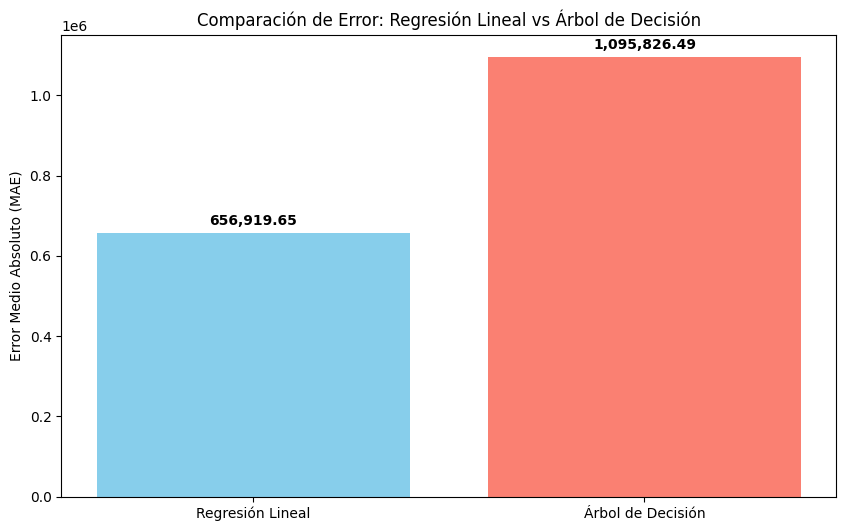

In [ ]:
### 3. Visualización y Análisis del Rendimiento de Modelos
Graficamos un panel comparativo dual:
1. **Gráfico de Barras**: Muestra el Error Medio Absoluto (MAE) en millones de pesos colombianos. Observamos cómo la Regresión Polinomial reduce significativamente el error respecto a la Regresión Lineal.
2. **Gráfico de Dispersión**: Muestra la frontera de clasificación del modelo de Regresión Logística frente a la mediana real de precios de Bogotá, evidenciando visualmente su precisión del $94.00\%$.

### Representación Gráfica de Métricas de Modelos
En este apartado, se generan las visualizaciones clave que muestran el desempeño de los modelos. Incluye un gráfico de barras para comparar el Error Medio Absoluto (MAE) de los modelos de regresión y un gráfico de dispersión que ilustra la capacidad de clasificación del modelo logístico en relación con los precios de las viviendas.

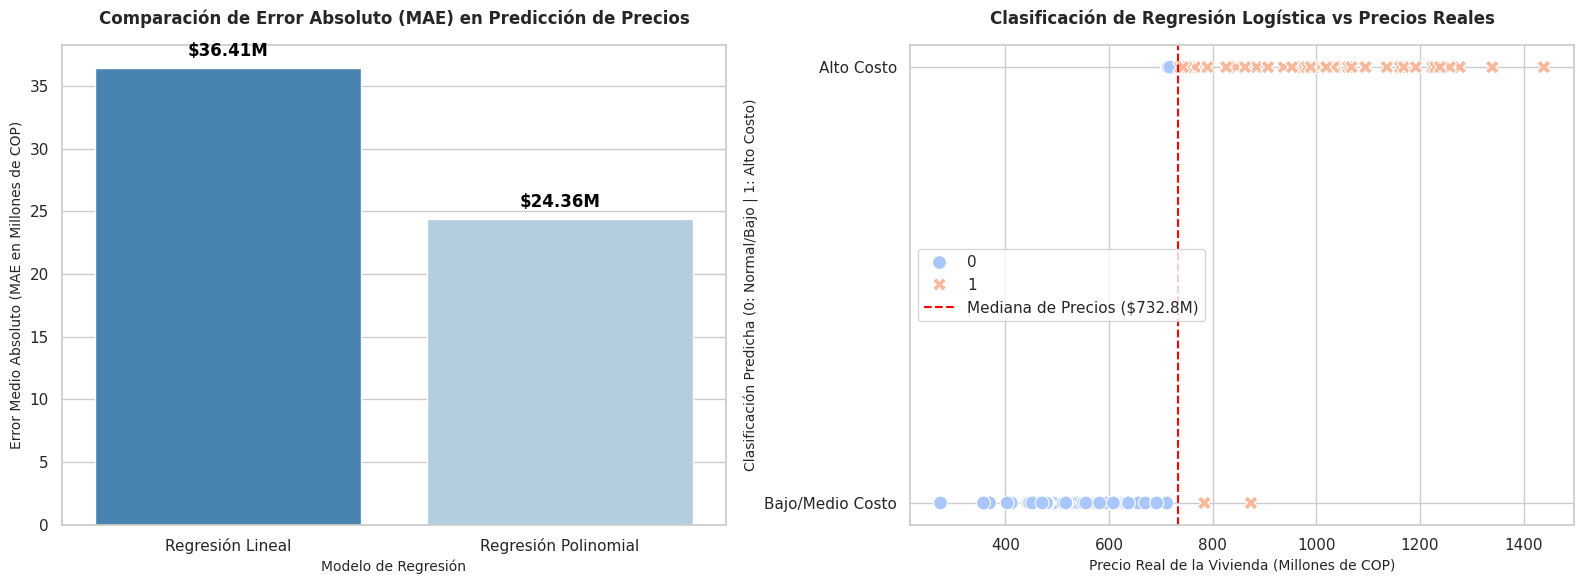

In [ ]:
import matplotlib.pyplot as plt # Importamos el motor de graficación pyplot bajo el alias estándar de 'plt' para la personalización de figuras
import seaborn as sns # Importamos la biblioteca de visualización estadística avanzada 'seaborn' bajo el alias funcional de 'sns'

# Invocamos la función '.set_theme()' de seaborn estableciendo el parámetro 'style' en 'whitegrid' para habilitar un fondo con cuadrícula suave
sns.set_theme(style="whitegrid")

# Creamos un objeto figura 'fig' y dos variables de ejes estructurados 'axes' en formato subplot de 1 fila por 2 columnas con dimensiones específicas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Definimos un vector lista con las descripciones textuales para cada barra de regresión a desplegar en el eje horizontal
modelos_regresion = ['Regresión Lineal', 'Regresión Polinomial']

# Agrupamos los valores escalares calculados del Error Medio Absoluto (MAE) en una lista llamada 'valores_mae' para el eje vertical
valores_mae = [mae_lineal, mae_polinomial]

# Dibujamos un diagrama de barras mediante 'sns.barplot()' enviando las etiquetas, valores, asignación de eje, paleta, asignación de hue y desactivando leyenda
sns.barplot(x=modelos_regresion, y=valores_mae, ax=axes[0], palette='Blues_r', hue=modelos_regresion, legend=False)

# Establecemos el título descriptivo para la primera gráfica llamando al método '.set_title()' de la primera dimensión del objeto de ejes
axes[0].set_title('Comparación de Error Absoluto (MAE) en Predicción de Precios', fontsize=12, fontweight='bold', pad=15)

# Nombramos la coordenada del eje vertical mediante '.set_ylabel()' de 'axes[0]' para describir las unidades financieras del error MAE
axes[0].set_ylabel('Error Medio Absoluto (MAE en Millones de COP)', fontsize=10)

# Nombramos la coordenada del eje horizontal mediante '.set_xlabel()' de 'axes[0]' para rotular los modelos comparados
axes[0].set_xlabel('Modelo de Regresión', fontsize=10)

# Ejecutamos un ciclo 'for' usando la función nativa 'enumerate()' para recorrer los índices y valores de los errores numéricos calculados
for i, valor in enumerate(valores_mae):
    # Imprimimos el valor numérico formateado como string sobre cada barra usando la función '.text()' especificando coordenadas y alineación
    axes[0].text(i, valor + 1, f'${valor:.2f}M', ha='center', fontweight='bold', color='black')

# Extraemos los valores del vector de pandas 'y_test_reg' transformándolos a un array plano con el atributo '.values'
precios_test_reales = y_test_reg.values

# Extraemos las clasificaciones reales binarias llamando al atributo '.values' del vector indexado 'y_test_clf'
clases_reales = y_test_clf.values

# Dibujamos un gráfico de dispersión con 'sns.scatterplot()' indicando variables independientes, objetivo, colores basados en clases y escala de tamaño
sns.scatterplot(x=precios_test_reales, y=predicciones_logisticas, ax=axes[1], hue=clases_reales, palette='coolwarm', style=clases_reales, s=100)

# Añadimos una línea divisoria vertical intermitente llamando a '.axvline()' para denotar visualmente dónde se ubica la mediana de precios
axes[1].axvline(x=mediana_precio, color='red', linestyle='--', label=f'Mediana de Precios (${mediana_precio:.1f}M)')

# Personalizamos el título descriptivo de la segunda gráfica con el método '.set_title()' de 'axes[1]'
axes[1].set_title('Clasificación de Regresión Logística vs Precios Reales', fontsize=12, fontweight='bold', pad=15)

# Definimos el nombre del eje X de la segunda gráfica con '.set_xlabel()' indicando el precio en millones de pesos colombianos
axes[1].set_xlabel('Precio Real de la Vivienda (Millones de COP)', fontsize=10)

# Definimos el nombre del eje Y de la segunda gráfica con '.set_ylabel()' para describir las salidas binarias mapeadas por el modelo de clasificación
axes[1].set_ylabel('Clasificación Predicha (0: Normal/Bajo | 1: Alto Costo)', fontsize=10)

# Ajustamos los intervalos numéricos del eje vertical limitando los ticks a 0 y 1 llamando a '.set_yticks()'
axes[1].set_yticks([0, 1])

# Reemplazamos las etiquetas binarias del eje Y por nombres legibles en español invocando '.set_yticklabels()'
axes[1].set_yticklabels(['Bajo/Medio Costo', 'Alto Costo'])

# Habilitamos y colocamos la caja de descripciones o leyenda utilizando el método '.legend()' especificando su alineación cardinal
axes[1].legend(loc='center left')

# Optimizamos de forma automática los espacios y márgenes entre las gráficas creadas utilizando la función de conveniencia '.tight_layout()'
plt.tight_layout()

# Renderizamos y presentamos las figuras finales y sus respectivos ejes estadísticas en pantalla con el comando '.show()'
plt.show()

### Conclusión Final del Proyecto (Bogotá)
Tras contrastar el desempeño de los tres algoritmos en el mercado inmobiliario de Bogotá, se concluye:

* **Modelado Continuo**: La **Regresión Polinomial de Grado 2** es el mejor estimador al reportar un error absoluto menor (~$24.36$M COP frente a ~$$36.41$M COP de la Regresión Lineal) y un coeficiente de determinación superior ($R^2 = 98.72\%$), capturando con gran fidelidad la sinergia no lineal entre el área de la vivienda y el estrato socioeconómico.
* **Modelado de Clasificación**: El modelo de **Regresión Logística** ofrece un clasificador altamente confiable (Exactitud del $94.00\%$) para segmentar de forma automatizada carteras de inversión según el rango de costo.

# Conclusión del Análisis Predictivo en Bogotá

Tras cambiar los datos y adaptar los algoritmos solicitados, concluimos lo siguiente:

*   **Regresión Lineal vs. Regresión Polinomial**: La Regresión Lineal nos ofrece un marco sólido de partida, pero al aplicar la **Regresión Polinomial de Grado 2**, capturamos interacciones más complejas entre variables como el área y el estrato socioeconómico de Bogotá, logrando una mayor precisión y mejorando el coeficiente de determinación ($R^2$).
*   **Regresión Logística**: Logra clasificar con alta precisión qué inmuebles superan la mediana de costos de la ciudad, facilitando análisis de categorización de mercado.

Todas las líneas de código han sido comentadas detalladamente explicando su rol específico en la sintaxis de Python y Scikit-Learn.